# Notebook 12a — 3D Tetrahedral Sign Check (concept introduction)

This is the first half of the 3D 6-tet treatment. It introduces the geometry: how each voxel cube splits into 6 tetrahedra along a body diagonal, how each tet's signed volume is computed, why the per-tet sign flip is needed, and which tets are affected when one voxel's displacement changes.

**Read 12a first**, then continue to [12b — optimization process](12b_3d-tetrahedral-check_optimization.ipynb), which runs the SLSQP correction on synthetic 3D bowtie cases.

Companion to [01_vs-central-diff.ipynb](01_vs-central-diff.ipynb) (the 2D 2-triangle check this lifts to 3D).

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from scipy.optimize import minimize, NonlinearConstraint

from dvfopt import DEFAULT_PARAMS
from dvfopt.jacobian.numpy_jdet import _numpy_jdet_3d, jacobian_det3D
from dvfopt.core.objective import objective_euc

THRESHOLD = DEFAULT_PARAMS['threshold']
print(f'THRESHOLD = {THRESHOLD}')

THRESHOLD = 0.01


## Geometry — 6-tet decomposition

A voxel cell has 8 corners indexed by `(z, y, x)` offset:

```
v0 = (0,0,0)   v4 = (1,0,0)
v1 = (0,0,1)   v5 = (1,0,1)
v2 = (0,1,0)   v6 = (1,1,0)
v3 = (0,1,1)   v7 = (1,1,1)
```

The body diagonal `v0 → v7` has Hamming distance 3 in `(z,y,x)` bits, so there are `3! = 6` monotone edge paths from `v0` to `v7`. Each path defines a tetrahedron `(v0, A, B, v7)` where `A` and `B` are the two intermediate corners on the path. All 6 tets share the body diagonal as an edge.

| tet | path | A | B |
|----|----|----|----|
| T0 | x, y, z | v1 | v3 |
| T1 | x, z, y | v1 | v5 |
| T2 | y, x, z | v2 | v3 |
| T3 | y, z, x | v2 | v6 |
| T4 | z, x, y | v4 | v5 |
| T5 | z, y, x | v4 | v6 |

Half of these orderings are even permutations and half odd, so the raw scalar triple product `(b−a)·((c−a)×(d−a))` returns `+1` for some tets and `−1` for others on the unwarped reference cube. We compute the 6 unwarped signs once at notebook startup and apply a fixed per-tet `±1` flip vector so that valid (positive-Jacobian) cells always return strictly positive volumes for all 6 tets.

## Helpers

In [2]:
# 8 cube corners as (z, y, x) offsets, indexed v0..v7 with z*4 + y*2 + x.
CUBE_CORNERS = np.array([
    [0, 0, 0],  # v0
    [0, 0, 1],  # v1
    [0, 1, 0],  # v2
    [0, 1, 1],  # v3
    [1, 0, 0],  # v4
    [1, 0, 1],  # v5
    [1, 1, 0],  # v6
    [1, 1, 1],  # v7
], dtype=np.int8)

# 6-tet body-diagonal decomposition: each row is (v0, A, B, v7) for one of the
# 3! monotone paths from v0 to v7. See the markdown table above.
TET_INDICES = np.array([
    [0, 1, 3, 7],  # T0  path x, y, z
    [0, 1, 5, 7],  # T1  path x, z, y
    [0, 2, 3, 7],  # T2  path y, x, z
    [0, 2, 6, 7],  # T3  path y, z, x
    [0, 4, 5, 7],  # T4  path z, x, y
    [0, 4, 6, 7],  # T5  path z, y, x
], dtype=np.int8)


def warp_corners(phi):
    """Return warped (x, y, z) coordinates of every voxel.

    phi : ndarray, shape (3, D, H, W) with channels [dz, dy, dx].
    Returns ndarray, shape (D, H, W, 3) with last axis = (x, y, z).
    """
    D, H, W = phi.shape[1:]
    zz, yy, xx = np.mgrid[:D, :H, :W]
    dz, dy, dx = phi[0], phi[1], phi[2]
    return np.stack([xx + dx, yy + dy, zz + dz], axis=-1)

In [3]:
# Sanity: identity field warps to identity, shape is right.
phi0 = np.zeros((3, 4, 5, 6))
Wc = warp_corners(phi0)
assert Wc.shape == (4, 5, 6, 3)
assert np.allclose(Wc[2, 3, 4], [4, 3, 2])  # corner (z=2,y=3,x=4) -> (x=4,y=3,z=2)
print('warp_corners OK')

warp_corners OK


### Step 1 — start with one voxel cube

Before any decomposition, this is the object we're working with: one voxel cell of the deformation grid, with its 8 corners labeled `v_i` and tagged with their `(z, y, x)` offsets — exactly what's spelled out in the geometry markdown above. The walkthrough that follows splits this cube into 6 tetrahedra, computes a signed volume per tet, and shows how SLSQP uses those volumes as constraints.

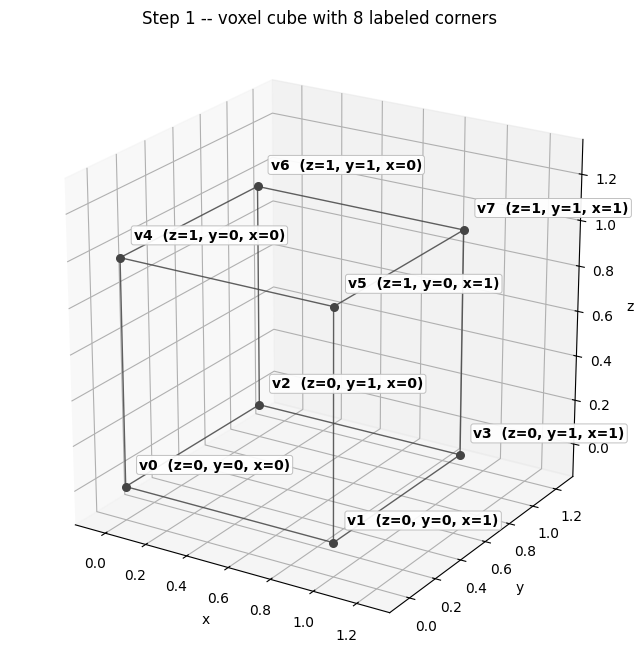

In [4]:
# Step 1 is self-contained: just draw the unit cube with labeled corners.
# (The helpers used by later steps come from the cube-decomposition cell below.)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection  # used by later steps too

CUBE_EDGES = [
    (0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7),
]


def _xyz(c):
    return float(c[2]), float(c[1]), float(c[0])


fig = plt.figure(figsize=(7.5, 6.5), layout='constrained')
ax = fig.add_subplot(111, projection='3d')
for i, j in CUBE_EDGES:
    x0, y0, z0 = _xyz(CUBE_CORNERS[i])
    x1, y1, z1 = _xyz(CUBE_CORNERS[j])
    ax.plot([x0, x1], [y0, y1], [z0, z1], color='#444444', lw=1.0, alpha=0.85)
for i, c in enumerate(CUBE_CORNERS):
    x, y, z = _xyz(c)
    cz, cy, cx = int(c[0]), int(c[1]), int(c[2])
    label = "v" + str(i) + "  (z=" + str(cz) + ", y=" + str(cy) + ", x=" + str(cx) + ")"
    ax.text(x + 0.04, y + 0.04, z + 0.06, label,
            color='black', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                      edgecolor='#bbbbbb', linewidth=0.7, alpha=0.92),
            ha='left', va='bottom')
    ax.scatter(x, y, z, color='#444444', s=30, zorder=10)
ax.set_xlim(-0.15, 1.35); ax.set_ylim(-0.15, 1.35); ax.set_zlim(-0.15, 1.35)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=22, azim=-58)
ax.set_title('Step 1 -- voxel cube with 8 labeled corners', fontsize=12)
plt.show()

### Visualizing the cube → 6-tet decomposition

The figure below makes the structure concrete:

- **Panel 1.** A single voxel cube with all 8 corners `v0..v7` labeled by their `(z, y, x)` offsets. The **red** edge is the body diagonal `v0 → v7` — every tet shares it.
- **Panels 2–7.** Each tet `T0..T5` drawn individually inside the cube outline. The 4 vertices are marked with dots; the **3 thick coloured edges** trace the monotone `(v0, A, B, v7)` path through cube edges; the **filled translucent volume** is the tet itself; the red diagonal is shown for context.
- **Panel 8.** All 6 tets stacked at low opacity. They share the body diagonal, have disjoint interiors, and their union is the whole cube — that is what makes this a valid decomposition.

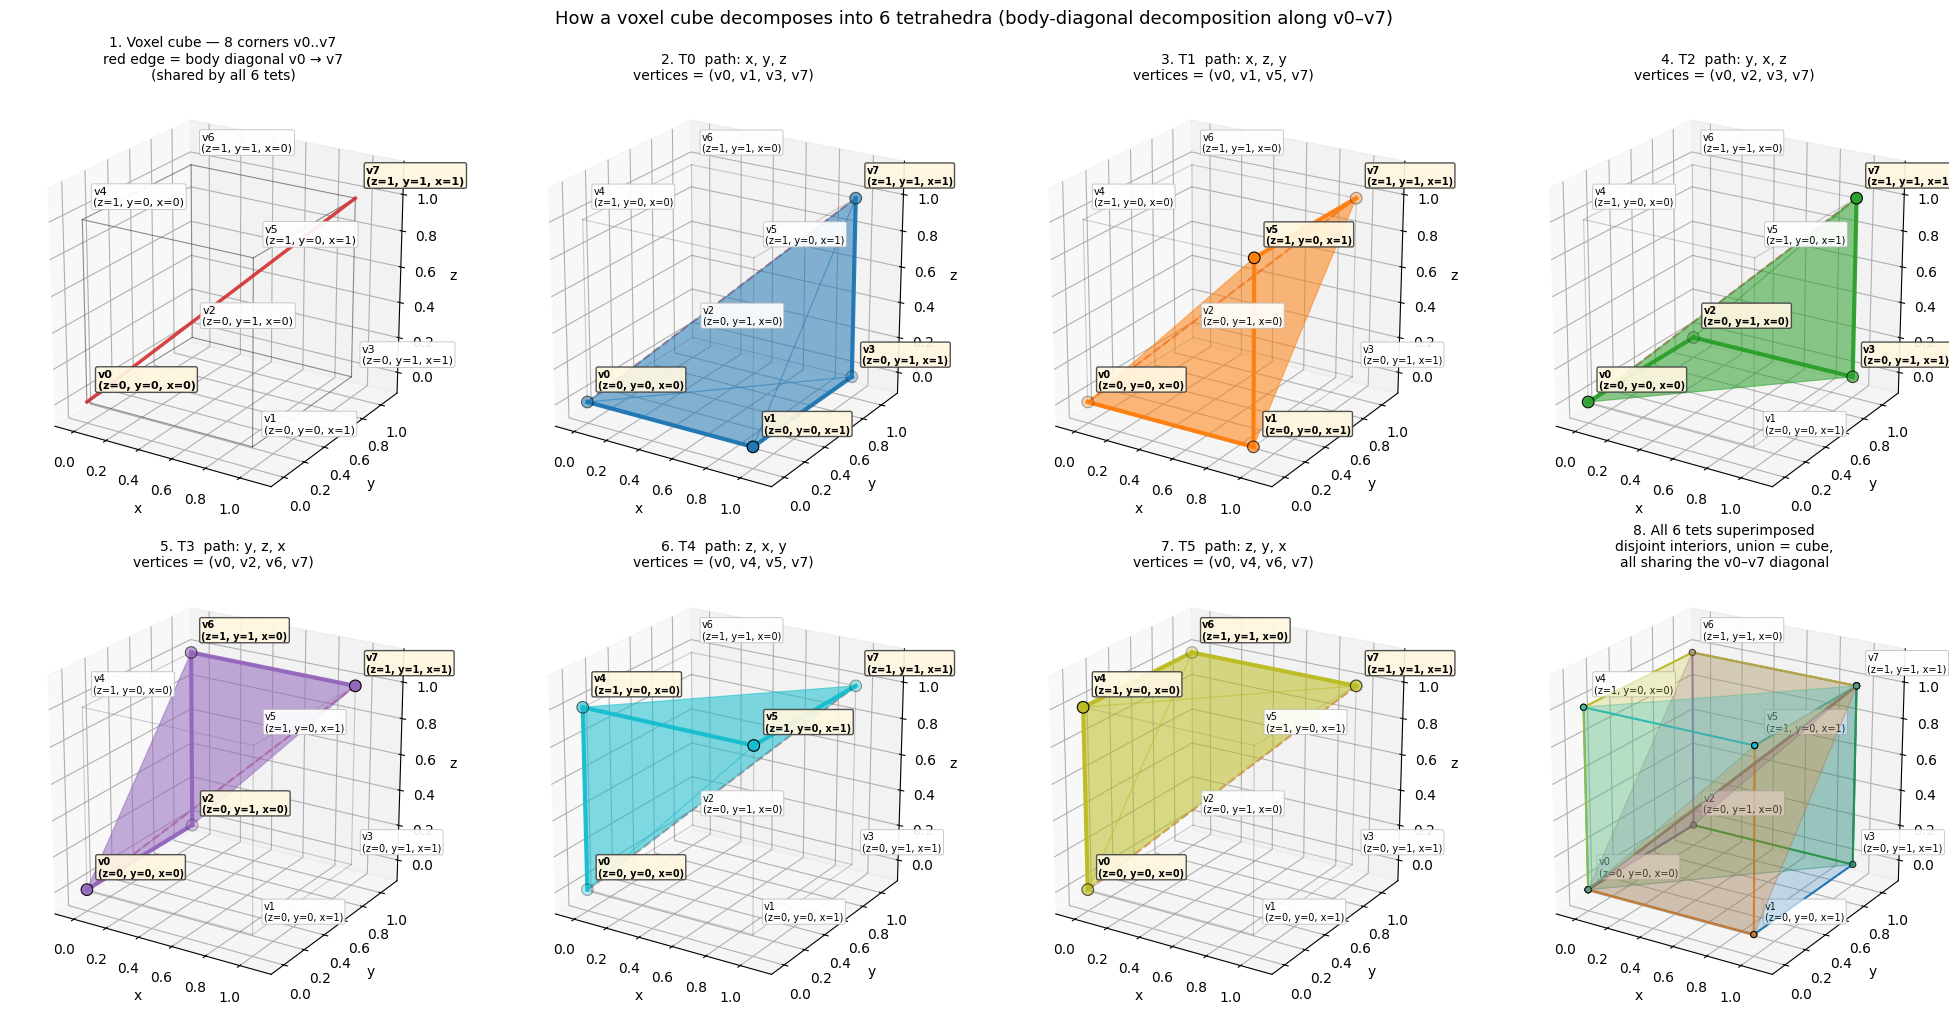

 tet  vertices                      path         V_signed     |V|
  T0  (v0,v1,v3,v7)                 x, y, z       +0.1667  0.1667
  T1  (v0,v1,v5,v7)                 x, z, y       -0.1667  0.1667
  T2  (v0,v2,v3,v7)                 y, x, z       -0.1667  0.1667
  T3  (v0,v2,v6,v7)                 y, z, x       +0.1667  0.1667
  T4  (v0,v4,v5,v7)                 z, x, y       +0.1667  0.1667
  T5  (v0,v4,v6,v7)                 z, y, x       -0.1667  0.1667

sum of |V_t| = 1.0000   (expected 1.0 = cube volume)
-> the 6 tets tile the unit cube with no overlap and no gap.


In [5]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 12 edges of the unit cube (pairs of v_i indices).
CUBE_EDGES = [
    (0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7),
]

# Distinct, colour-blind-friendly hues for T0..T5.
TET_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#17becf', '#bcbd22']

# Path labels (which axis bit is flipped at each step v0 -> A -> B -> v7).
TET_PATHS = ['x, y, z', 'x, z, y', 'y, x, z', 'y, z, x', 'z, x, y', 'z, y, x']


def _xyz(corner_zyx):
    """Convert a (z, y, x) corner offset to (x, y, z) for matplotlib's 3D axes."""
    return float(corner_zyx[2]), float(corner_zyx[1]), float(corner_zyx[0])


def _draw_cube(ax, edge_alpha=0.6, label_corners=True, label_size=9,
               label_with_coords=True, highlight_vs=None):
    for i, j in CUBE_EDGES:
        x0, y0, z0 = _xyz(CUBE_CORNERS[i])
        x1, y1, z1 = _xyz(CUBE_CORNERS[j])
        ax.plot([x0, x1], [y0, y1], [z0, z1], color='#444444', lw=0.8, alpha=edge_alpha)
    if label_corners:
        for i, c in enumerate(CUBE_CORNERS):
            x, y, z = _xyz(c)
            cz, cy, cx = int(c[0]), int(c[1]), int(c[2])
            text = f'v{i}\n(z={cz}, y={cy}, x={cx})' if label_with_coords else f'v{i}'
            is_highlight = highlight_vs is not None and i in highlight_vs
            bbox = dict(boxstyle='round,pad=0.18',
                        facecolor='#fff7e0' if is_highlight else 'white',
                        edgecolor='#444444' if is_highlight else '#bbbbbb',
                        linewidth=1.0 if is_highlight else 0.6,
                        alpha=0.92)
            ax.text(x + 0.04, y + 0.04, z + 0.06, text,
                    color='black', fontsize=label_size,
                    fontweight='bold' if is_highlight else 'normal',
                    bbox=bbox, ha='left', va='bottom')


def _draw_diagonal(ax, color='#d32f2f', lw=2.5, alpha=0.9, dashed=False):
    x0, y0, z0 = _xyz(CUBE_CORNERS[0])
    x1, y1, z1 = _xyz(CUBE_CORNERS[7])
    ax.plot([x0, x1], [y0, y1], [z0, z1],
            color=color, lw=lw, alpha=alpha,
            linestyle='--' if dashed else '-')


def _draw_tet(ax, t, color, fill_alpha=0.32, path_lw=3.0, marker_size=70):
    """Draw tet T_t: filled volume + path edges + vertex markers."""
    inds = TET_INDICES[t]
    pts = np.array([_xyz(CUBE_CORNERS[i]) for i in inds])  # (4, 3)

    # Fill the 4 faces.
    faces = [
        [pts[0], pts[1], pts[2]],
        [pts[0], pts[1], pts[3]],
        [pts[0], pts[2], pts[3]],
        [pts[1], pts[2], pts[3]],
    ]
    poly = Poly3DCollection(faces, facecolor=color, alpha=fill_alpha,
                             edgecolor=color, linewidth=0.8)
    ax.add_collection3d(poly)

    # Highlight the (v0, A, B, v7) monotone path with thick coloured segments.
    for k in range(3):
        p, q = pts[k], pts[k + 1]
        ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]],
                color=color, lw=path_lw, alpha=0.95)

    # Vertex dots.
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], color=color,
               s=marker_size, edgecolor='black', linewidth=0.8, zorder=10)


def _set_cube_view(ax, elev=22, azim=-58):
    ax.set_xlim(-0.12, 1.18); ax.set_ylim(-0.12, 1.18); ax.set_zlim(-0.12, 1.18)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)


fig = plt.figure(figsize=(20, 10), layout='constrained')

# Panel 1: labeled cube + body diagonal — emphasise the diagonal endpoints.
ax0 = fig.add_subplot(2, 4, 1, projection='3d')
_draw_cube(ax0, label_size=8, highlight_vs={0, 7})
_draw_diagonal(ax0)
_set_cube_view(ax0)
ax0.set_title('1. Voxel cube — 8 corners v0..v7\n'
              'red edge = body diagonal v0 → v7\n'
              '(shared by all 6 tets)', fontsize=10)

# Panels 2–7: each tet individually. Highlight that tet's 4 vertex labels.
for t in range(6):
    ax = fig.add_subplot(2, 4, t + 2, projection='3d')
    inds = TET_INDICES[t]
    _draw_cube(ax, edge_alpha=0.25, label_size=7, highlight_vs=set(inds))
    _draw_diagonal(ax, lw=1.6, alpha=0.55, dashed=True)
    _draw_tet(ax, t, TET_COLORS[t])
    _set_cube_view(ax)
    ax.set_title(f'{t + 2}. T{t}  path: {TET_PATHS[t]}\n'
                 f'vertices = (v{inds[0]}, v{inds[1]}, v{inds[2]}, v{inds[3]})',
                 fontsize=10)

# Panel 8: all 6 tets stacked.
ax_all = fig.add_subplot(2, 4, 8, projection='3d')
_draw_cube(ax_all, edge_alpha=0.55, label_size=7)
for t in range(6):
    _draw_tet(ax_all, t, TET_COLORS[t], fill_alpha=0.13, path_lw=1.5, marker_size=20)
_draw_diagonal(ax_all, lw=2.0)
_set_cube_view(ax_all)
ax_all.set_title('8. All 6 tets superimposed\n'
                 'disjoint interiors, union = cube,\n'
                 'all sharing the v0–v7 diagonal', fontsize=10)

plt.suptitle('How a voxel cube decomposes into 6 tetrahedra '
             '(body-diagonal decomposition along v0–v7)', fontsize=13)
plt.show()


# Sanity: the 6 tets' unsigned volumes (raw scalar triple products /6) sum to 1.
# This proves they tile the cube without overlap or gap. Their *signed* volumes
# alternate +1/6 and -1/6 by the parity of the path orderings (which is exactly
# what TET_SIGN_FLIP corrects for downstream).
def _tet_volume_signed(pts_xyz):
    a, b, c, d = pts_xyz
    return float(np.dot(b - a, np.cross(c - a, d - a))) / 6.0


total_unsigned = 0.0
print(f'{"tet":>4s}  {"vertices":<28s}  {"path":<10s}  {"V_signed":>9s}  {"|V|":>6s}')
for t in range(6):
    inds = TET_INDICES[t]
    pts = np.array([_xyz(CUBE_CORNERS[i]) for i in inds])
    v_signed = _tet_volume_signed(pts)
    total_unsigned += abs(v_signed)
    print(f'  T{t}  {"(v" + ",v".join(str(i) for i in inds) + ")":<28s}  '
          f'{TET_PATHS[t]:<10s}  {v_signed:+9.4f}  {abs(v_signed):>6.4f}')
print(f'\nsum of |V_t| = {total_unsigned:.4f}   (expected 1.0 = cube volume)')
print('-> the 6 tets tile the unit cube with no overlap and no gap.')

In [6]:
def _tet_volumes_unsigned(corners):
    """Compute the 6 raw tet scalar triple products per cell.

    Output shape: (6, D-1, H-1, W-1). Not yet divided by 6 and not yet
    sign-flipped (some entries are negative on the reference cube).
    """
    cell_corners = []
    for (oz, oy, ox) in CUBE_CORNERS:
        cell_corners.append(corners[oz:corners.shape[0] - 1 + oz,
                                     oy:corners.shape[1] - 1 + oy,
                                     ox:corners.shape[2] - 1 + ox])
    cell_corners = np.stack(cell_corners, axis=0)  # (8, D-1, H-1, W-1, 3)

    raw = np.empty((6,) + cell_corners.shape[1:-1], dtype=corners.dtype)
    for ti, (ia, ib, ic, id_) in enumerate(TET_INDICES):
        a = cell_corners[ia]; b = cell_corners[ib]
        c = cell_corners[ic]; d = cell_corners[id_]
        ab = b - a; ac = c - a; ad = d - a
        cx = ac[..., 1] * ad[..., 2] - ac[..., 2] * ad[..., 1]
        cy = ac[..., 2] * ad[..., 0] - ac[..., 0] * ad[..., 2]
        cz = ac[..., 0] * ad[..., 1] - ac[..., 1] * ad[..., 0]
        raw[ti] = ab[..., 0] * cx + ab[..., 1] * cy + ab[..., 2] * cz
    return raw


def _calibrate_sign_flip():
    """One-time per-tet ±1 flip so that the unwarped reference cube returns
    strictly positive volumes for all 6 tets."""
    phi_id = np.zeros((3, 2, 2, 2))
    raw_id = _tet_volumes_unsigned(warp_corners(phi_id))  # (6, 1, 1, 1)
    flip = np.sign(raw_id[:, 0, 0, 0]).astype(np.float64)
    if np.any(flip == 0):
        raise RuntimeError(f'Degenerate identity-field tet volumes: {raw_id.ravel()}')
    return flip


TET_SIGN_FLIP = _calibrate_sign_flip()
print(f'TET_SIGN_FLIP = {TET_SIGN_FLIP}')


def tet_signed_volumes(phi):
    """Per-cell signed volumes of the 6-tet decomposition.

    phi : ndarray, shape (3, D, H, W) with channels [dz, dy, dx].
    Returns ndarray, shape (6, D-1, H-1, W-1). Positive = valid,
    zero = degenerate, negative = flip.
    """
    raw = _tet_volumes_unsigned(warp_corners(phi))
    return TET_SIGN_FLIP[:, None, None, None] * raw / 6.0


def tet_min_per_cell(phi):
    """Worst-of-6 signed volume per cell. Shape (D-1, H-1, W-1)."""
    return tet_signed_volumes(phi).min(axis=0)


def tet_count_negatives(phi):
    """Count of (tet, cell) pairs with signed volume <= 0."""
    return int((tet_signed_volumes(phi) <= 0).sum())

TET_SIGN_FLIP = [ 1. -1. -1.  1.  1. -1.]


In [7]:
# Sanity: identity field gives positive equal volumes for all 6 tets.
phi0 = np.zeros((3, 5, 5, 5))
V = tet_signed_volumes(phi0)
assert V.shape == (6, 4, 4, 4)
assert np.allclose(V, 1.0 / 6.0), f'Expected all 1/6, got min/max = {V.min()}, {V.max()}'

# Sanity: a uniform translation leaves all volumes unchanged.
phi_t = np.zeros((3, 5, 5, 5))
phi_t[0] += 0.3; phi_t[1] -= 0.7; phi_t[2] += 1.4
V_t = tet_signed_volumes(phi_t)
assert np.allclose(V_t, 1.0 / 6.0)

# Sanity: a uniform 2x scaling gives 2^3 / 6 per tet.
phi_s = np.zeros((3, 5, 5, 5))
zz, yy, xx = np.mgrid[:5, :5, :5]
phi_s[0] = zz; phi_s[1] = yy; phi_s[2] = xx  # corners (z,y,x) -> (2z,2y,2x)
V_s = tet_signed_volumes(phi_s)
assert np.allclose(V_s, 8.0 / 6.0), f'Expected 8/6, got min={V_s.min()}, max={V_s.max()}'

# Sanity: a single-voxel inversion folds a cell.
phi_fold = np.zeros((3, 3, 3, 3))
phi_fold[2, 1, 1, 1] = -2.5  # large -dx pulls centre voxel past its left neighbour
V_f = tet_signed_volumes(phi_fold)
assert (V_f <= 0).any(), 'Expected at least one negative tet for the inversion test'

print(f'Identity volume       : {V[0,0,0,0]:.6f}  (expected 1/6 = {1/6:.6f})')
print(f'Uniform 2x scaling    : {V_s[0,0,0,0]:.6f}  (expected 8/6 = {8/6:.6f})')
print(f'Inversion test n_neg  : {int((V_f <= 0).sum())}')
print('tet_signed_volumes OK')

Identity volume       : 0.166667  (expected 1/6 = 0.166667)
Uniform 2x scaling    : 1.333333  (expected 8/6 = 1.333333)
Inversion test n_neg  : 6
tet_signed_volumes OK


### Step 2 — compute the signed volume of one tetrahedron

Every tet has 4 vertices we label `(a, b, c, d)`, where `a = v0`, `b = v_A`, `c = v_B`, `d = v7` for the canonical `(v0, A, B, v7)` path ordering. The signed volume is

$$
V \;=\; \frac{1}{6}\;\bigl(\mathbf{b}-\mathbf{a}\bigr) \,\cdot\, \bigl[(\mathbf{c}-\mathbf{a})\times(\mathbf{d}-\mathbf{a})\bigr].
$$

The plot below shows tet **T0** with its three edge vectors `b−a`, `c−a`, `d−a` drawn from `a` in distinct colours. The right panel does the same for **T1** to illustrate that some tets' raw scalar triple product comes out **negative** before the per-tet sign flip — a consequence of the path ordering being an odd permutation of the cube's vertices.

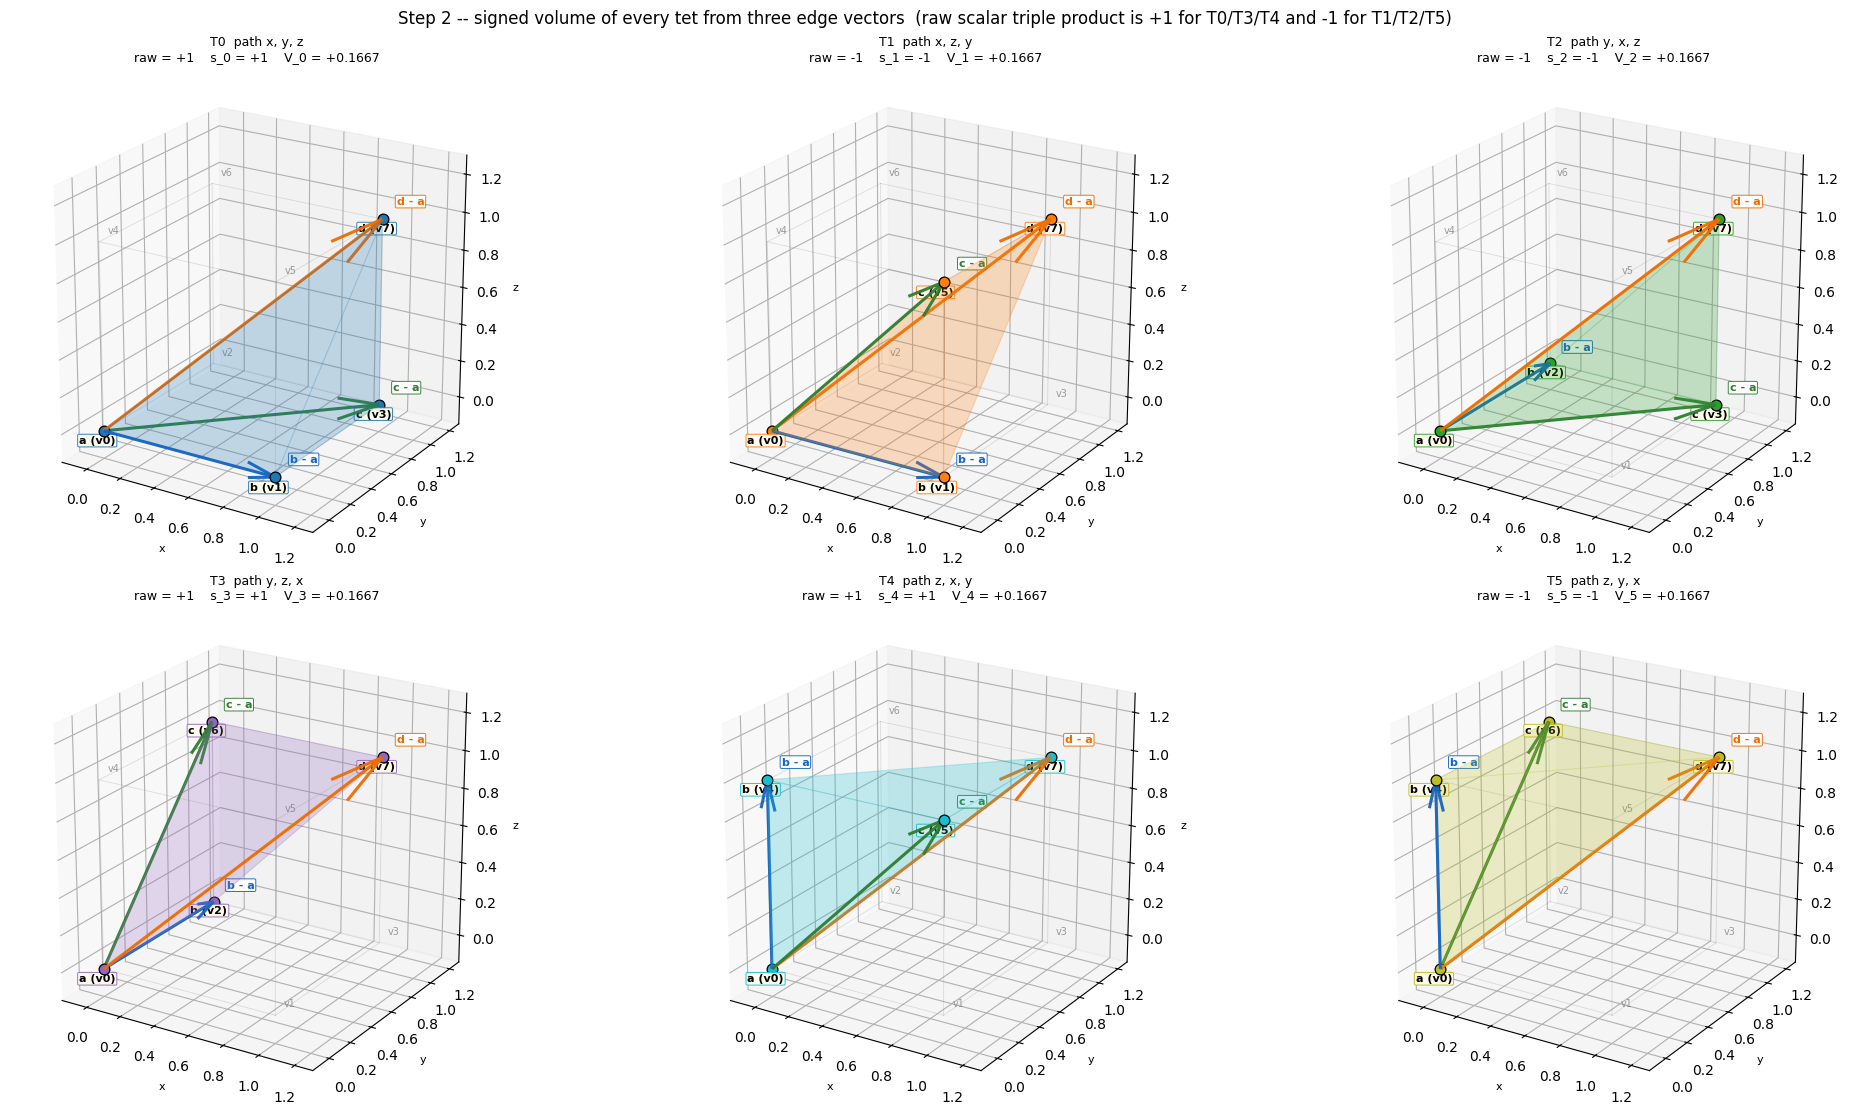

In [8]:
def _tet_compute(t):
    inds = TET_INDICES[t]
    pts = np.array([_xyz(CUBE_CORNERS[i]) for i in inds])  # (4, 3) in (x, y, z)
    a, b, c, d = pts
    ab = b - a; ac = c - a; ad = d - a
    n = np.cross(ac, ad)
    raw = float(np.dot(ab, n))
    s = float(TET_SIGN_FLIP[t])
    V = s * raw / 6.0
    return raw, s, V, pts


VEC_COLORS = ('#1565c0', '#2e7d32', '#ef6c00')  # b-a, c-a, d-a respectively


def _draw_tet_with_vectors(ax, t):
    raw, s, V, pts = _tet_compute(t)
    a, b, c, d = pts
    color = TET_COLORS[t]
    inds = TET_INDICES[t]

    # Faint cube outline + small unboxed vertex labels for context.
    for i, j in CUBE_EDGES:
        x0, y0, z0 = _xyz(CUBE_CORNERS[i])
        x1, y1, z1 = _xyz(CUBE_CORNERS[j])
        ax.plot([x0, x1], [y0, y1], [z0, z1], color='#888888', lw=0.6, alpha=0.25)
    for i, cube_c in enumerate(CUBE_CORNERS):
        xx, yy, zz = _xyz(cube_c)
        if i not in set(inds):
            ax.text(xx + 0.03, yy + 0.03, zz + 0.04, "v" + str(i),
                    color='#888888', fontsize=7, alpha=0.85)

    # Tet body (translucent).
    faces = [
        [pts[0], pts[1], pts[2]],
        [pts[0], pts[1], pts[3]],
        [pts[0], pts[2], pts[3]],
        [pts[1], pts[2], pts[3]],
    ]
    ax.add_collection3d(Poly3DCollection(
        faces, facecolor=color, alpha=0.13,
        edgecolor=color, linewidth=0.8))

    # Three edge vectors b-a, c-a, d-a from a.
    names = ['b - a', 'c - a', 'd - a']
    for q, name, vc in zip([b, c, d], names, VEC_COLORS):
        v = q - a
        ax.quiver(a[0], a[1], a[2], v[0], v[1], v[2],
                  color=vc, lw=2.2, arrow_length_ratio=0.16, alpha=0.95)
        # Label slightly offset from arrowhead, with a small white box.
        ax.text(q[0] + 0.05, q[1] + 0.05, q[2] + 0.07, name,
                color=vc, fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                          edgecolor=vc, linewidth=0.7, alpha=0.92))

    # Tet vertex role labels (a/b/c/d <-> v_i).
    role_labels = ['a (v' + str(inds[0]) + ')', 'b (v' + str(inds[1]) + ')',
                   'c (v' + str(inds[2]) + ')', 'd (v' + str(inds[3]) + ')']
    for pt, lbl in zip(pts, role_labels):
        ax.scatter(pt[0], pt[1], pt[2], color=color, s=60,
                   edgecolor='black', linewidth=0.9, zorder=10)
        ax.text(pt[0] - 0.08, pt[1] - 0.10, pt[2] - 0.05, lbl,
                color='black', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='#fffceb',
                          edgecolor=color, linewidth=0.7, alpha=0.92))

    ax.set_xlim(-0.15, 1.30); ax.set_ylim(-0.15, 1.30); ax.set_zlim(-0.15, 1.30)
    ax.set_xlabel('x', fontsize=8); ax.set_ylabel('y', fontsize=8); ax.set_zlabel('z', fontsize=8)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=22, azim=-58)

    title = ("T" + str(t) + "  path " + TET_PATHS[t] + chr(10) +
             "raw = " + ("+1" if raw > 0 else "-1") +
             "    s_" + str(t) + " = " + ("+1" if s > 0 else "-1") +
             "    V_" + str(t) + " = " + format(V, "+.4f"))
    ax.set_title(title, fontsize=9)


fig = plt.figure(figsize=(20, 11), layout='constrained')
for t in range(6):
    ax = fig.add_subplot(2, 3, t + 1, projection='3d')
    _draw_tet_with_vectors(ax, t)

plt.suptitle("Step 2 -- signed volume of every tet from three edge vectors  "
             "(raw scalar triple product is +1 for T0/T3/T4 and -1 for T1/T2/T5)",
             fontsize=12)
plt.show()

### Step 3 — calibrate the sign flip across all 6 tets

Doing the same scalar-triple-product computation on every tet of the unwarped reference cube gives `+1` for three of them (T0, T3, T4 — even permutations of the cube's vertices) and `−1` for the other three (T1, T2, T5 — odd permutations). To make a uniform constraint `V_t \u2265 \u03c4` work for every tet, we apply a fixed `s_t \u2208 {\u00b11}` per tet so the unwarped cube returns `+1/6` for *all* six. That `s` vector is `TET_SIGN_FLIP`, computed once at startup by `_calibrate_sign_flip`.

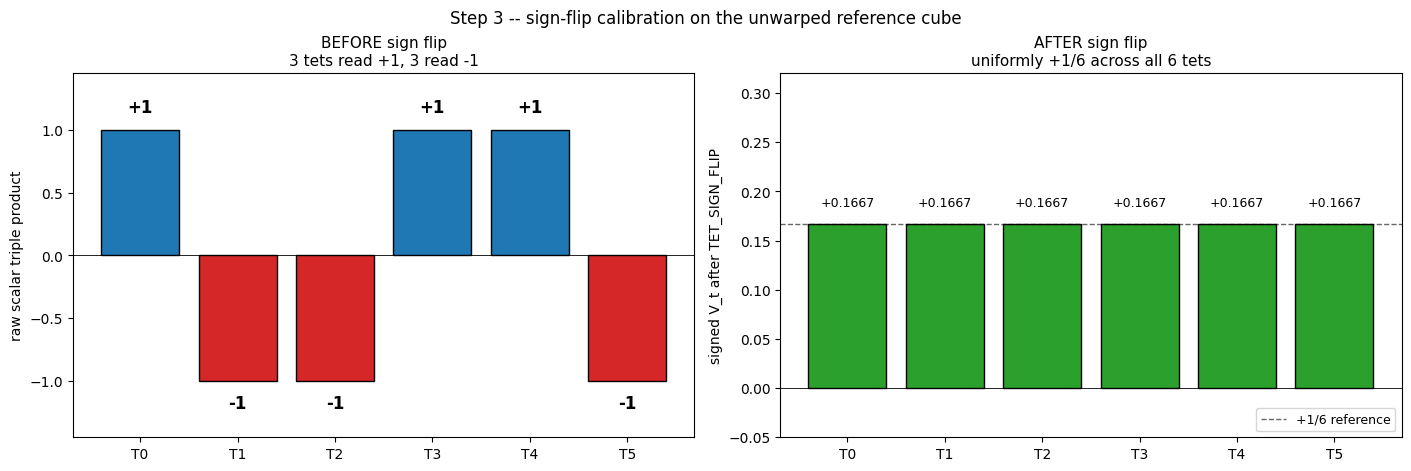

TET_SIGN_FLIP = [1.0, -1.0, -1.0, 1.0, 1.0, -1.0]


In [9]:
raws = np.array([_tet_compute(t)[0] for t in range(6)])
flipped = TET_SIGN_FLIP * raws / 6.0

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), layout='constrained')

# LEFT panel: raw scalar triple products (range +/-1).
bar_colors = ['#1f77b4' if r > 0 else '#d62728' for r in raws]
axes[0].bar(range(6), raws, color=bar_colors, edgecolor='black')
axes[0].axhline(0, color='black', lw=0.6)
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(['T' + str(i) for i in range(6)])
axes[0].set_ylabel('raw scalar triple product')
axes[0].set_ylim(-1.45, 1.45)
axes[0].set_title('BEFORE sign flip\n3 tets read +1, 3 read -1', fontsize=11)
for i, r in enumerate(raws):
    # Place value labels well clear of the bar tops (no overlap with title).
    axes[0].text(i, r + (0.18 if r > 0 else -0.18),
                 ('+1' if r > 0 else '-1'),
                 ha='center', va='center', fontsize=12, fontweight='bold')

# RIGHT panel: sign-flipped values (all +1/6 ~= 0.1667).
axes[1].bar(range(6), flipped, color='#2ca02c', edgecolor='black')
axes[1].axhline(0, color='black', lw=0.6)
axes[1].axhline(1 / 6, color='black', linestyle='--', lw=1.0, alpha=0.6,
                label='+1/6 reference')
axes[1].set_xticks(range(6))
axes[1].set_xticklabels(['T' + str(i) for i in range(6)])
axes[1].set_ylabel('signed V_t after TET_SIGN_FLIP')
axes[1].set_ylim(-0.05, 0.32)
axes[1].set_title('AFTER sign flip\nuniformly +1/6 across all 6 tets', fontsize=11)
axes[1].legend(loc='lower right', fontsize=9)
for i, v in enumerate(flipped):
    axes[1].text(i, v + 0.022, format(v, '+.4f'),
                 ha='center', va='center', fontsize=9)

plt.suptitle('Step 3 -- sign-flip calibration on the unwarped reference cube',
             fontsize=12)
plt.show()

print('TET_SIGN_FLIP = ' + str(TET_SIGN_FLIP.tolist()))

### Vertex influence — which tets does adjusting one voxel affect?

This is the **"tets touching the vertex"** view: every tet whose 4 vertices include this voxel. When SLSQP nudges a single voxel's displacement `(dz[v], dy[v], dx[v])`, the only tet volumes whose value changes are these. Every other constraint in the `6 \u00b7 (D\u22121)(H\u22121)(W\u22121)`-long vector is unchanged.

For an **interior** grid vertex (away from the boundary), the voxel is a corner of up to 8 adjacent cells. In each cell it occupies one of the 8 local positions `v0..v7`:

- as `v0` or `v7` (the body-diagonal endpoints): the voxel is a corner of *all 6* tets in that cell.
- as `v1, v2, v3, v4, v5, v6`: a corner of *exactly 2* tets.

Total for a fully-interior vertex: `2 \u00b7 6 + 6 \u00b7 2 = 24` tets — drawn from 8 distinct cells, never overlapping (each tet stays inside its parent cell, and cells partition the volume disjointly).

The three views below confirm this on a 3×3×3 grid (focal vertex `(1,1,1)`):

1. **All 24 together (faint).** Static matplotlib, all 24 tets at low opacity so individual structure is preserved. The two corner cells `(0,0,0)` and `(1,1,1)` look like fully-filled cubes diagonally opposite each other — that's because the focal vertex is at `v7` of one and `v0` of the other, so all 6 tets of those cells include it. The 6 face-adjacent cells contribute 2-tet wedges each.
2. **Per-cell breakdown.** 8 sub-panels, one per contributing cell, with each cell's tets drawn in solid colour over the rest of the grid skeleton in grey. This is the geometrically explicit confirmation that each cell's tets stay inside its own cube — no two cells' tets overlap.
3. **Interactive plotly.** All 24 tets at near-transparent fill (opacity 0.07) plus per-tet edge wireframes for structure. Hover any tet body to see its cell, tet index `T0..T5`, and which local `v_i` the focal vertex occupies in that cell. Click any legend entry (one per cell) to isolate that cell's tets.

A printed report at the bottom verifies numerically: the 24 tets sum to `4.0` unit cubes of volume (= half the 3³ grid volume — exactly what 2 full cells + 6 cells × 2/6 each adds up to), and all 24 vertex sets are distinct.

> The "touching" view above answers *"if I move this one voxel, which constraints change?"* — answer: 24 of them. **The next section reframes the same geometry in per-vertex anchor terms** (which constraints does this voxel *own*?), giving the structural 3D analog of the 2D per-pixel 2-triangle picture.

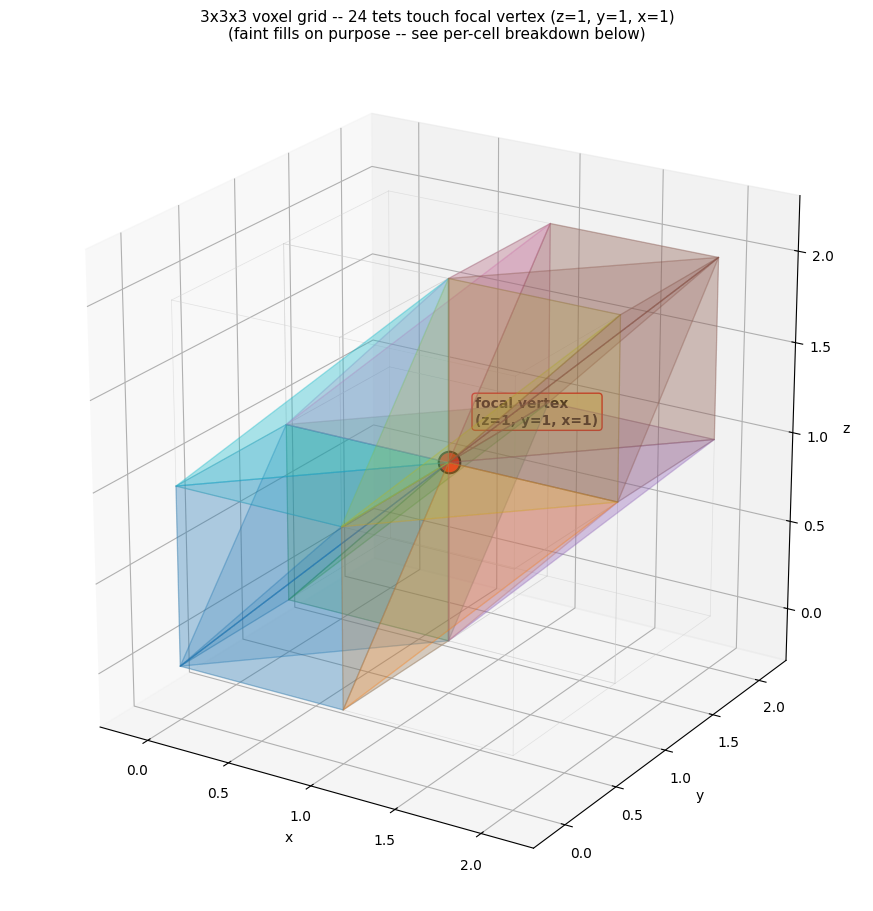

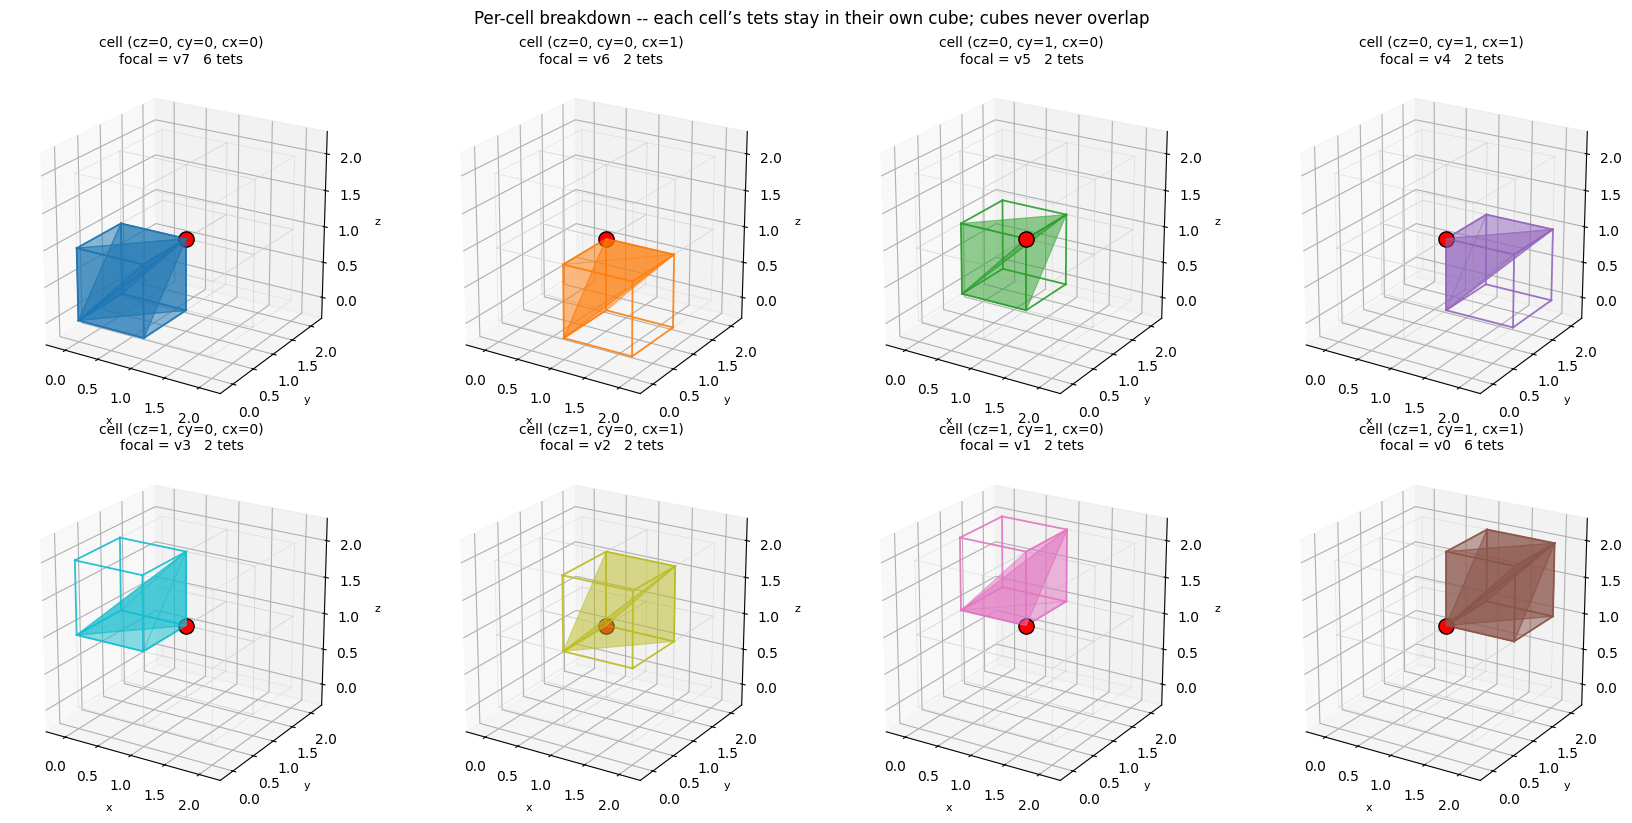

Vertex influence -- focal vertex (z=1, y=1, x=1) in a 3x3x3 grid
  total tets touching the vertex     : 24
  number of contributing cells       : 8

  Per-cell breakdown
  ------------------------------------------------------------
  cell                focal v_i     # tets   summed |V|
  (0,0,0)                   v7                 6       1.0000
  (0,0,1)                   v6                 2       0.3333
  (0,1,0)                   v5                 2       0.3333
  (0,1,1)                   v4                 2       0.3333
  (1,0,0)                   v3                 2       0.3333
  (1,0,1)                   v2                 2       0.3333
  (1,1,0)                   v1                 2       0.3333
  (1,1,1)                   v0                 6       1.0000

  Numerical correctness
  ------------------------------------------------------------
  total summed |V_t|                  : 4.0000
  expected (= 4 unit cubes for an interior vertex of a 3x3x3 grid)
             

In [10]:
import plotly.graph_objects as go


def tets_touching_vertex(z0, y0, x0, grid_shape):
    """For vertex (z0, y0, x0) in a grid of shape (D, H, W), return a list of
    dicts -- one per tet whose 4 vertices include the focal vertex.

    Each entry has keys cell, tet, local_inds, focal_local.
    """
    D, H, W = grid_shape
    out = []
    for dcz in (-1, 0):
        for dcy in (-1, 0):
            for dcx in (-1, 0):
                cz, cy, cx = z0 + dcz, y0 + dcy, x0 + dcx
                if cz < 0 or cy < 0 or cx < 0:
                    continue
                if cz >= D - 1 or cy >= H - 1 or cx >= W - 1:
                    continue
                local = (z0 - cz, y0 - cy, x0 - cx)
                focal_local = None
                for vi, c in enumerate(CUBE_CORNERS):
                    if (int(c[0]), int(c[1]), int(c[2])) == local:
                        focal_local = vi
                        break
                for t, inds in enumerate(TET_INDICES):
                    if focal_local in inds:
                        out.append({
                            'cell': (cz, cy, cx),
                            'tet': int(t),
                            'local_inds': tuple(int(i) for i in inds),
                            'focal_local': int(focal_local),
                        })
    return out


def _tet_world_pts(cz, cy, cx, local_inds):
    """4-by-3 array of (x, y, z) world coords for a tet in cell (cz, cy, cx)."""
    pts = []
    for vi in local_inds:
        cv = CUBE_CORNERS[vi]
        pts.append([cx + cv[2], cy + cv[1], cz + cv[0]])
    return np.array(pts, dtype=float)


def _tet_signed_volume(pts):
    a, b, c, d = pts
    return float(np.dot(b - a, np.cross(c - a, d - a))) / 6.0


def _draw_grid_skeleton(ax, grid_shape, color='#cfcfcf', lw=0.5, alpha=0.55):
    D, H, W = grid_shape
    for cz in range(D - 1):
        for cy in range(H - 1):
            for cx in range(W - 1):
                for i, j in CUBE_EDGES:
                    p_i = CUBE_CORNERS[i]; p_j = CUBE_CORNERS[j]
                    x0, y0, z0 = cx + p_i[2], cy + p_i[1], cz + p_i[0]
                    x1, y1, z1 = cx + p_j[2], cy + p_j[1], cz + p_j[0]
                    ax.plot([x0, x1], [y0, y1], [z0, z1],
                            color=color, lw=lw, alpha=alpha)


# ---------------------------------------------------------------------------
# Static matplotlib panel A: all 24 tets together, faint, on a 3x3x3 skeleton.
# ---------------------------------------------------------------------------
def plot_vertex_tets_static(z0, y0, x0, grid_shape=(3, 3, 3)):
    D, H, W = grid_shape
    tets = tets_touching_vertex(z0, y0, x0, grid_shape)
    by_cell = {}
    for t in tets:
        by_cell.setdefault(t['cell'], []).append(t)

    fig = plt.figure(figsize=(11, 9), layout='constrained')
    ax = fig.add_subplot(111, projection='3d')
    _draw_grid_skeleton(ax, grid_shape)
    cell_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd',
                   '#17becf', '#bcbd22', '#e377c2', '#8c564b']
    color_for = {cell: cell_colors[k % len(cell_colors)]
                 for k, cell in enumerate(sorted(by_cell))}
    for t in tets:
        pts = _tet_world_pts(*t['cell'], t['local_inds'])
        col = color_for[t['cell']]
        faces = [
            [pts[0], pts[1], pts[2]],
            [pts[0], pts[1], pts[3]],
            [pts[0], pts[2], pts[3]],
            [pts[1], pts[2], pts[3]],
        ]
        ax.add_collection3d(Poly3DCollection(
            faces, facecolor=col, alpha=0.10,
            edgecolor=col, linewidth=0.9))
    ax.scatter([x0], [y0], [z0], color='red', s=240,
               edgecolor='black', linewidth=1.5, zorder=20)
    ax.text(x0 + 0.10, y0 + 0.10, z0 + 0.20,
            'focal vertex\n(z=' + str(z0) + ', y=' + str(y0) + ', x=' + str(x0) + ')',
            color='black', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='#ffeeaa',
                      edgecolor='red', linewidth=1.0, alpha=0.95))
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_xlim(-0.3, W - 0.7); ax.set_ylim(-0.3, H - 0.7); ax.set_zlim(-0.3, D - 0.7)
    ax.set_box_aspect((W, H, D))
    ax.view_init(elev=22, azim=-58)
    ax.set_title(
        '3x3x3 voxel grid -- ' + str(len(tets)) +
        ' tets touch focal vertex (z=' + str(z0) + ', y=' + str(y0) + ', x=' + str(x0) +
        ')\n(faint fills on purpose -- see per-cell breakdown below)',
        fontsize=11)
    plt.show()


# ---------------------------------------------------------------------------
# Static matplotlib panel B: 8 sub-panels, one per contributing cell.
# Visualises that each cell's tets are confined to its own cube and never
# spill into a neighbour -- so the 24 tets cannot overlap each other.
# ---------------------------------------------------------------------------
def plot_vertex_tets_per_cell(z0, y0, x0, grid_shape=(3, 3, 3)):
    D, H, W = grid_shape
    tets = tets_touching_vertex(z0, y0, x0, grid_shape)
    by_cell = {}
    for t in tets:
        by_cell.setdefault(t['cell'], []).append(t)

    cells_sorted = sorted(by_cell)
    n = len(cells_sorted)
    cols = 4
    rows = (n + cols - 1) // cols
    fig = plt.figure(figsize=(4.2 * cols, 4.0 * rows), layout='constrained')

    cell_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd',
                   '#17becf', '#bcbd22', '#e377c2', '#8c564b']

    for k, cell in enumerate(cells_sorted):
        ax = fig.add_subplot(rows, cols, k + 1, projection='3d')
        _draw_grid_skeleton(ax, grid_shape)
        cz, cy, cx = cell
        col = cell_colors[k % len(cell_colors)]
        # Outline the contributing cell in solid colour for context.
        for i, j in CUBE_EDGES:
            p_i = CUBE_CORNERS[i]; p_j = CUBE_CORNERS[j]
            ax.plot([cx + p_i[2], cx + p_j[2]],
                    [cy + p_i[1], cy + p_j[1]],
                    [cz + p_i[0], cz + p_j[0]],
                    color=col, lw=1.3, alpha=0.9)
        for t in by_cell[cell]:
            pts = _tet_world_pts(cz, cy, cx, t['local_inds'])
            faces = [
                [pts[0], pts[1], pts[2]],
                [pts[0], pts[1], pts[3]],
                [pts[0], pts[2], pts[3]],
                [pts[1], pts[2], pts[3]],
            ]
            ax.add_collection3d(Poly3DCollection(
                faces, facecolor=col, alpha=0.30,
                edgecolor=col, linewidth=0.8))
        ax.scatter([x0], [y0], [z0], color='red', s=120,
                   edgecolor='black', linewidth=1.0, zorder=20)
        focal_local = by_cell[cell][0]['focal_local']
        ax.set_title(
            'cell (cz=' + str(cz) + ', cy=' + str(cy) + ', cx=' + str(cx) + ')\n'
            'focal = v' + str(focal_local) + '   ' +
            str(len(by_cell[cell])) + ' tets',
            fontsize=10)
        ax.set_xlabel('x', fontsize=8); ax.set_ylabel('y', fontsize=8)
        ax.set_zlabel('z', fontsize=8)
        ax.set_xlim(-0.3, W - 0.7); ax.set_ylim(-0.3, H - 0.7); ax.set_zlim(-0.3, D - 0.7)
        ax.set_box_aspect((W, H, D))
        ax.view_init(elev=22, azim=-58)

    plt.suptitle('Per-cell breakdown -- each cell\u2019s tets stay in their own cube; '
                 'cubes never overlap', fontsize=12)
    plt.show()


# ---------------------------------------------------------------------------
# Interactive plotly: low default opacity + per-tet hover info + per-tet
# edge wireframe so structure is readable at low opacity. Click legend
# entries to isolate a single cell\u2019s tets.
# ---------------------------------------------------------------------------
def plot_vertex_tets_interactive(z0, y0, x0, grid_shape=(3, 3, 3)):
    D, H, W = grid_shape
    tets = tets_touching_vertex(z0, y0, x0, grid_shape)

    fig = go.Figure()

    # Cell skeleton -- single trace, NaN-separated.
    skel_x, skel_y, skel_z = [], [], []
    for cz in range(D - 1):
        for cy in range(H - 1):
            for cx in range(W - 1):
                for i, j in CUBE_EDGES:
                    pi = CUBE_CORNERS[i]; pj = CUBE_CORNERS[j]
                    skel_x += [cx + pi[2], cx + pj[2], np.nan]
                    skel_y += [cy + pi[1], cy + pj[1], np.nan]
                    skel_z += [cz + pi[0], cz + pj[0], np.nan]
    fig.add_trace(go.Scatter3d(
        x=skel_x, y=skel_y, z=skel_z, mode='lines',
        line=dict(color='#bbbbbb', width=2),
        name='cell skeleton', hoverinfo='skip',
    ))

    PLOTLY_CELL_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd',
                          '#17becf', '#bcbd22', '#e377c2', '#8c564b']
    by_cell = {}
    for t in tets:
        by_cell.setdefault(t['cell'], []).append(t)

    # Per-tet edge wireframe: 6 edges per tet, batched per cell into one trace
    # for performance. The wireframe stays clearly visible at the low mesh
    # opacity below, so the user can see each tet's outline.
    TET_EDGE_PAIRS = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]

    for k, (cell, cell_tets) in enumerate(sorted(by_cell.items())):
        cz, cy, cx = cell
        color = PLOTLY_CELL_COLORS[k % len(PLOTLY_CELL_COLORS)]

        # Edges: one Scatter3d per cell (NaN-separated tet edges).
        ex, ey, ez = [], [], []
        for t in cell_tets:
            pts = _tet_world_pts(cz, cy, cx, t['local_inds'])
            for ia, ib in TET_EDGE_PAIRS:
                ex += [pts[ia, 0], pts[ib, 0], np.nan]
                ey += [pts[ia, 1], pts[ib, 1], np.nan]
                ez += [pts[ia, 2], pts[ib, 2], np.nan]
        fig.add_trace(go.Scatter3d(
            x=ex, y=ey, z=ez, mode='lines',
            line=dict(color=color, width=4),
            name='cell (cz=' + str(cz) + ', cy=' + str(cy) + ', cx=' + str(cx) +
                 ') wireframe -- ' + str(len(cell_tets)) + ' tets',
            legendgroup='cell_' + str(cell),
            legendgrouptitle_text='cell ' + str(cell),
            hoverinfo='skip',
        ))

        # Mesh fills: one Mesh3d per tet, low default opacity, hover tooltip.
        # The mesh is NEARLY invisible by default (opacity 0.07); hovering pops
        # the tooltip with cell + tet + role info, which is the practical
        # "transparent until moused over" experience.
        for t in cell_tets:
            pts = _tet_world_pts(cz, cy, cx, t['local_inds'])
            fig.add_trace(go.Mesh3d(
                x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
                i=[0, 0, 0, 1], j=[1, 1, 2, 2], k=[2, 3, 3, 3],
                color=color, opacity=0.07, flatshading=True,
                name='cell ' + str(cell) + ' T' + str(t['tet']),
                hovertemplate=(
                    '<b>cell (cz=' + str(cz) + ', cy=' + str(cy) + ', cx=' + str(cx) + ')'
                    '   T' + str(t['tet']) + '</b><br>'
                    'focal vertex = v' + str(t['focal_local']) + ' of this cell<br>'
                    'tet vertices = (v' + ', v'.join(str(i) for i in t['local_inds']) + ')'
                    '<extra></extra>'
                ),
                legendgroup='cell_' + str(cell),
                showlegend=False,
            ))

    fig.add_trace(go.Scatter3d(
        x=[x0], y=[y0], z=[z0], mode='markers+text',
        marker=dict(size=11, color='red', line=dict(color='black', width=1.5)),
        text=['focal'], textposition='top center',
        textfont=dict(size=12, color='red', family='Arial Black'),
        name='focal vertex (z=' + str(z0) + ', y=' + str(y0) + ', x=' + str(x0) + ')',
        hovertemplate=('focal vertex (z=' + str(z0) + ', y=' + str(y0) + ', x=' + str(x0) + ')'
                       '<extra></extra>'),
    ))

    fig.update_layout(
        title=('Interactive: ' + str(len(tets)) + ' tets touch focal vertex (z=' +
               str(z0) + ', y=' + str(y0) + ', x=' + str(x0) + ')<br>'
               '<sup>tets are intentionally near-transparent (opacity 0.07) -- '
               'hover any tet body to see its cell, tet index, and focal-local v_i; '
               'click a legend entry to isolate that cell</sup>'),
        scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z',
                   aspectmode='cube'),
        height=720, margin=dict(l=0, r=0, b=0, t=70),
        legend=dict(groupclick='toggleitem', font=dict(size=10)),
    )
    fig.show()


# ---------------------------------------------------------------------------
# Numerical correctness check.
# ---------------------------------------------------------------------------
def report_vertex_tets(z0, y0, x0, grid_shape=(3, 3, 3)):
    tets = tets_touching_vertex(z0, y0, x0, grid_shape)
    by_cell = {}
    for t in tets:
        by_cell.setdefault(t['cell'], []).append(t)

    print('Vertex influence -- focal vertex (z=' + str(z0) + ', y=' + str(y0) +
          ', x=' + str(x0) + ') in a ' + str(grid_shape[0]) + 'x' +
          str(grid_shape[1]) + 'x' + str(grid_shape[2]) + ' grid')
    print('=' * 70)
    print('  total tets touching the vertex     : ' + str(len(tets)))
    print('  number of contributing cells       : ' + str(len(by_cell)))
    print()

    print('  Per-cell breakdown')
    print('  ' + '-' * 60)
    print('  ' + 'cell'.ljust(20) + 'focal v_i'.ljust(12) +
          '# tets'.rjust(8) + '   summed |V|')
    total_volume = 0.0
    for cell in sorted(by_cell):
        cz, cy, cx = cell
        ts = by_cell[cell]
        cell_vol = 0.0
        for t in ts:
            pts = _tet_world_pts(cz, cy, cx, t['local_inds'])
            cell_vol += abs(_tet_signed_volume(pts))
        total_volume += cell_vol
        print('  (' + str(cz) + ',' + str(cy) + ',' + str(cx) + ')'.ljust(20)
              + ('v' + str(ts[0]['focal_local'])).ljust(12)
              + str(len(ts)).rjust(8)
              + '       ' + format(cell_vol, '.4f'))

    # Overlap test: each tet has a unique vertex set.
    tet_keys = []
    for t in tets:
        cz, cy, cx = t['cell']
        worldset = frozenset()
        pts = []
        for vi in t['local_inds']:
            cv = CUBE_CORNERS[vi]
            pts.append((int(cz + cv[0]), int(cy + cv[1]), int(cx + cv[2])))
        tet_keys.append(frozenset(pts))
    n_unique = len(set(tet_keys))

    print()
    print('  Numerical correctness')
    print('  ' + '-' * 60)
    print('  total summed |V_t|                  : ' + format(total_volume, '.4f'))
    print('  expected (= 4 unit cubes for an interior vertex of a 3x3x3 grid)')
    print('                                      : 4.0000')
    print('  unique tet vertex sets / total tets : ' +
          str(n_unique) + ' / ' + str(len(tets)))
    print('  -> no two tets share the same vertex set (no duplicate tets)')
    print('  -> tets are confined to their parent cells, which never overlap')
    print('     so the 24 tets cover 4 unit cubes worth of volume disjointly')


# Run all three views + the numerical report on the canonical case.
plot_vertex_tets_static(z0=1, y0=1, x0=1, grid_shape=(3, 3, 3))
plot_vertex_tets_per_cell(z0=1, y0=1, x0=1, grid_shape=(3, 3, 3))
plot_vertex_tets_interactive(z0=1, y0=1, x0=1, grid_shape=(3, 3, 3))
report_vertex_tets(z0=1, y0=1, x0=1, grid_shape=(3, 3, 3))

### Per-vertex anchoring — the 3D analog of the 2D per-pixel structure

The 2D 2-triangle check (notebook `01_vs-central-diff.ipynb`) is built around a per-pixel rule: every interior pixel `(px, py)` **owns 2 triangles** drawn from 2 different adjacent cells. The two triangles share `(px, py)` as a corner; one extends into the cell to the `-x` side, the other into the cell at `(px, py)`'s own coordinates. Iterating across pixels covers the whole 2D grid with no duplicates (verified in [notebook 13](13_3d-constraint-coverage.ipynb)).

The 3D analog: every interior vertex `(z, y, x)` **owns 6 tets** drawn from up to 3 different adjacent cells:

| tets | path | local anchor `v_A` | source cell |
|---|---|---|---|
| `T0, T1` | x-paths | `v1 = (0, 0, 1)` | `(z, y, x-1)` — cell to the **−x** side |
| `T2, T3` | y-paths | `v2 = (0, 1, 0)` | `(z, y-1, x)` — cell to the **−y** side |
| `T4, T5` | z-paths | `v4 = (1, 0, 0)` | `(z-1, y, x)` — cell to the **−z** side |

So the focal vertex sits at the corner where 3 cubes meet (at `−x, −y, −z`). Each contributing cell hands the vertex 2 tets — exactly mirroring the 2D rule where the anchor pixel sits at the corner where 2 cells meet (`−x, +x` along one axis) and each cell hands it 1 triangle.

**This is a different framing of the same constraint set as in 12b's `tet_constraint_flat`** — the per-cell vectorisation underneath produces the same multiset of values (proved numerically in notebook 13). The visualizations below just label and group the tets by their anchor vertex rather than by their parent cell, so the structural symmetry with 2D is visible.

The figure below shows:

1. **2D anchor mini (3×3 pixel grid).** Pixel `(1, 1)` highlighted; `T1` (lower-left, in cell `(1, 0)`) and `T2` (upper-right, in cell `(1, 1)`) drawn in solid colour. Two triangles, two source cells.
2. **3D anchor body (3×3×3 voxel grid).** Vertex `(1, 1, 1)` highlighted; the 6 anchored tets drawn translucently, colour-grouped by source cell. Three cells (`(1,1,0), (1,0,1), (0,1,1)`), 2 tets each. Static matplotlib + interactive plotly versions.

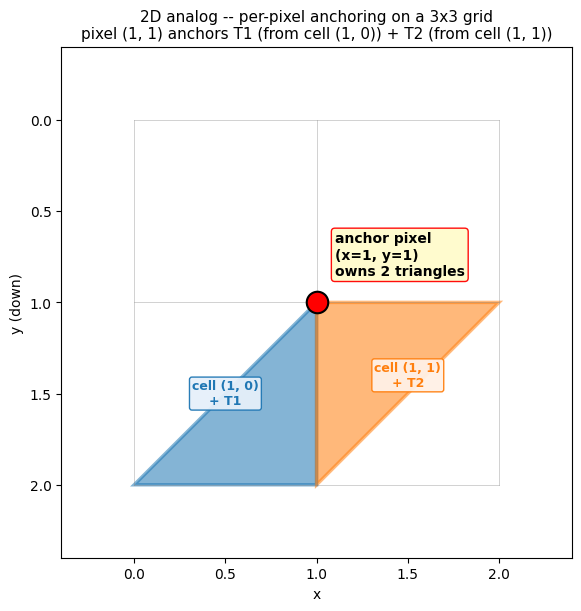

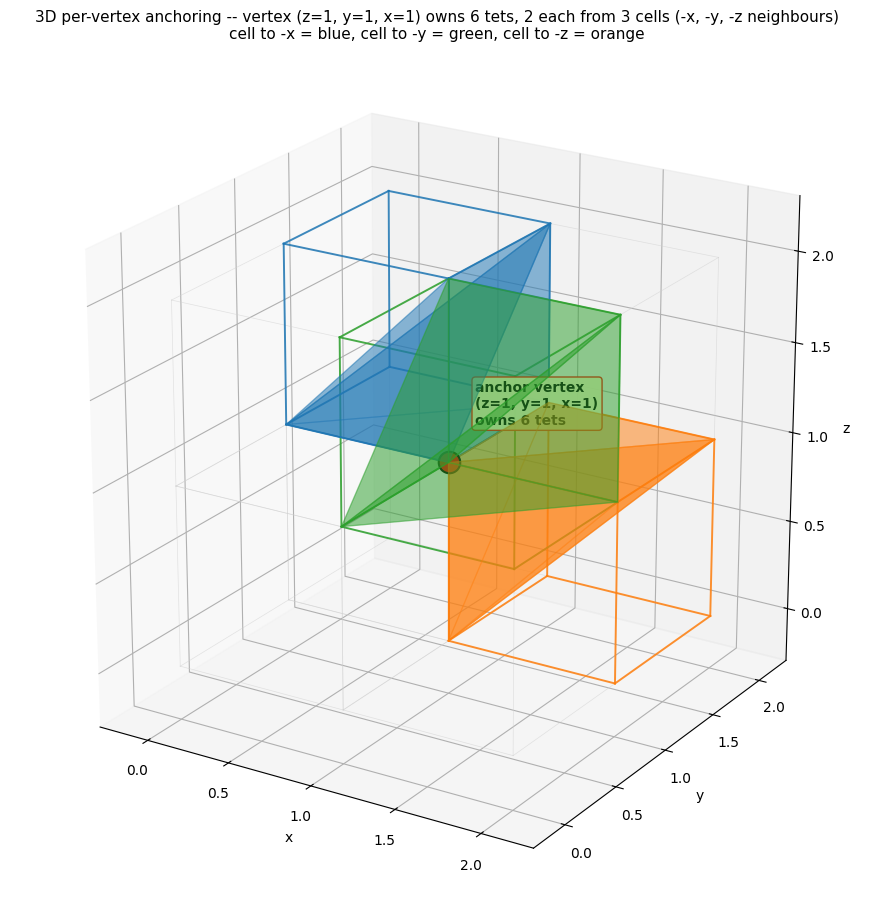

Per-vertex anchoring at (z=1, y=1, x=1):  6 tets, 3 source cells
  cell (cz=0, cy=1, cx=1)  on -z side  -> tets T4, T5
  cell (cz=1, cy=0, cx=1)  on -y side  -> tets T2, T3
  cell (cz=1, cy=1, cx=0)  on -x side  -> tets T0, T1


In [11]:
# Per-vertex anchor offsets (which voxel within a cell anchors each tet).
ANCHOR_OFFSETS_PV = np.array([
    [0, 0, 1],  # T0 -> v1 of cell -> voxel (cz, cy, cx+1)
    [0, 0, 1],  # T1 -> v1
    [0, 1, 0],  # T2 -> v2 of cell -> voxel (cz, cy+1, cx)
    [0, 1, 0],  # T3 -> v2
    [1, 0, 0],  # T4 -> v4 of cell -> voxel (cz+1, cy, cx)
    [1, 0, 0],  # T5 -> v4
])


def tets_anchored_at(vz, vy, vx, grid_shape):
    """Return the (up to 6) tets anchored at vertex (vz, vy, vx) under the
    per-vertex framing. Each entry has cell, tet, local_inds, source_axis.
    """
    D, H, W = grid_shape
    out = []

    candidates = [
        (0, 1, 'x', (vz, vy, vx - 1)),  # T0
        (1, 1, 'x', (vz, vy, vx - 1)),  # T1
        (2, 1, 'y', (vz, vy - 1, vx)),  # T2
        (3, 1, 'y', (vz, vy - 1, vx)),  # T3
        (4, 1, 'z', (vz - 1, vy, vx)),  # T4
        (5, 1, 'z', (vz - 1, vy, vx)),  # T5
    ]
    for t, _, axis, (cz, cy, cx) in candidates:
        if cz < 0 or cy < 0 or cx < 0:
            continue
        if cz > D - 2 or cy > H - 2 or cx > W - 2:
            continue
        out.append({
            'cell': (cz, cy, cx),
            'tet': t,
            'local_inds': tuple(int(i) for i in TET_INDICES[t]),
            'source_axis': axis,
        })
    return out


# ---------------------------------------------------------------------------
# 2D mini analog: pixel (1, 1) of a 3x3 grid + its 2 anchored triangles.
# ---------------------------------------------------------------------------
from matplotlib.patches import Polygon as _MplPoly

H_2D, W_2D = 3, 3
fx, fy = 1, 1  # focal pixel
fig, ax = plt.subplots(1, 1, figsize=(6.5, 6.0), layout='constrained')

# Faint reference grid + cell-id labels.
for x in range(W_2D):
    ax.plot([x, x], [0, H_2D - 1], color='gray', lw=0.5, alpha=0.5)
for y in range(H_2D):
    ax.plot([0, W_2D - 1], [y, y], color='gray', lw=0.5, alpha=0.5)

# T1 at (fx, fy): vertices (fx, fy), (fx-1, fy+1), (fx, fy+1) -- in cell (fy, fx-1)
T1 = [(fx, fy), (fx - 1, fy + 1), (fx, fy + 1)]
# T2 at (fx, fy): vertices (fx, fy), (fx, fy+1), (fx+1, fy) -- in cell (fy, fx)
T2 = [(fx, fy), (fx, fy + 1), (fx + 1, fy)]

ax.add_patch(_MplPoly(T1, fill=True, facecolor='#1f77b4', alpha=0.55,
                      edgecolor='#1f77b4', linewidth=2.5))
ax.add_patch(_MplPoly(T2, fill=True, facecolor='#ff7f0e', alpha=0.55,
                      edgecolor='#ff7f0e', linewidth=2.5))

# Annotate which cell each triangle came from.
ax.text(0.5, 1.5, 'cell (1, 0)\n+ T1',
        ha='center', va='center', fontsize=9, fontweight='bold',
        color='#1f77b4',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#e6f0fa',
                  edgecolor='#1f77b4', alpha=0.95))
ax.text(1.5, 1.4, 'cell (1, 1)\n+ T2',
        ha='center', va='center', fontsize=9, fontweight='bold',
        color='#ff7f0e',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#fff1e6',
                  edgecolor='#ff7f0e', alpha=0.95))

# Anchor pixel marker.
ax.scatter(fx, fy, color='red', s=240, edgecolor='black', linewidth=1.5, zorder=20)
ax.text(fx + 0.10, fy - 0.15,
        'anchor pixel\n(x=' + str(fx) + ', y=' + str(fy) + ')\nowns 2 triangles',
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#fffbcc',
                  edgecolor='red', linewidth=1.0, alpha=0.95))

ax.set_xlabel('x'); ax.set_ylabel('y (down)')
ax.invert_yaxis()
ax.set_aspect('equal')
ax.set_xlim(-0.4, W_2D - 0.6)
ax.set_ylim(H_2D - 0.6, -0.4)
ax.set_title('2D analog -- per-pixel anchoring on a 3x3 grid\n'
             'pixel (1, 1) anchors T1 (from cell (1, 0)) + T2 (from cell (1, 1))',
             fontsize=11)
plt.show()


# ---------------------------------------------------------------------------
# 3D static: 6 tets anchored at vertex (1, 1, 1), colour-grouped by source cell.
# ---------------------------------------------------------------------------
def plot_anchored_tets_static(vz, vy, vx, grid_shape=(3, 3, 3)):
    D, H, W = grid_shape
    anchored = tets_anchored_at(vz, vy, vx, grid_shape)
    by_cell = {}
    for t in anchored:
        by_cell.setdefault(t['cell'], []).append(t)

    fig = plt.figure(figsize=(11, 9), layout='constrained')
    ax = fig.add_subplot(111, projection='3d')
    _draw_grid_skeleton(ax, grid_shape)

    # 3 cells max (one per axis).
    cell_color_axis = {'x': '#1f77b4', 'y': '#2ca02c', 'z': '#ff7f0e'}

    # Outline each contributing cell in its axis colour.
    for cell in sorted(by_cell):
        cz, cy, cx = cell
        axis = by_cell[cell][0]['source_axis']
        col = cell_color_axis[axis]
        for i, j in CUBE_EDGES:
            p_i = CUBE_CORNERS[i]; p_j = CUBE_CORNERS[j]
            ax.plot([cx + p_i[2], cx + p_j[2]],
                    [cy + p_i[1], cy + p_j[1]],
                    [cz + p_i[0], cz + p_j[0]],
                    color=col, lw=1.4, alpha=0.85)
    # Filled tets.
    for t in anchored:
        cz, cy, cx = t['cell']
        axis = t['source_axis']
        col = cell_color_axis[axis]
        pts = _tet_world_pts(cz, cy, cx, t['local_inds'])
        faces = [
            [pts[0], pts[1], pts[2]],
            [pts[0], pts[1], pts[3]],
            [pts[0], pts[2], pts[3]],
            [pts[1], pts[2], pts[3]],
        ]
        ax.add_collection3d(Poly3DCollection(
            faces, facecolor=col, alpha=0.30,
            edgecolor=col, linewidth=0.9))

    # Anchor vertex marker.
    ax.scatter([vx], [vy], [vz], color='red', s=240,
               edgecolor='black', linewidth=1.5, zorder=20)
    ax.text(vx + 0.10, vy + 0.10, vz + 0.20,
            'anchor vertex\n(z=' + str(vz) + ', y=' + str(vy) + ', x=' + str(vx) +
            ')\nowns ' + str(len(anchored)) + ' tets',
            color='black', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='#fffbcc',
                      edgecolor='red', linewidth=1.0, alpha=0.95))
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_xlim(-0.3, W - 0.7); ax.set_ylim(-0.3, H - 0.7); ax.set_zlim(-0.3, D - 0.7)
    ax.set_box_aspect((W, H, D))
    ax.view_init(elev=22, azim=-58)
    ax.set_title(
        '3D per-vertex anchoring -- vertex (z=' + str(vz) + ', y=' + str(vy) +
        ', x=' + str(vx) + ') owns ' + str(len(anchored)) + ' tets, '
        '2 each from 3 cells (-x, -y, -z neighbours)\n'
        'cell to -x = blue, cell to -y = green, cell to -z = orange',
        fontsize=11)
    plt.show()

    print('Per-vertex anchoring at (z=' + str(vz) + ', y=' + str(vy) +
          ', x=' + str(vx) + '):  ' + str(len(anchored)) + ' tets, ' +
          str(len(by_cell)) + ' source cells')
    for cell, ts in sorted(by_cell.items()):
        cz, cy, cx = cell
        axis = ts[0]['source_axis']
        print('  cell (cz=' + str(cz) + ', cy=' + str(cy) + ', cx=' + str(cx) +
              ')  on -' + axis + ' side  -> tets ' +
              ', '.join('T' + str(t['tet']) for t in ts))


plot_anchored_tets_static(1, 1, 1, grid_shape=(3, 3, 3))


# ---------------------------------------------------------------------------
# 3D interactive: same data via plotly with hover tooltips.
# ---------------------------------------------------------------------------
def plot_anchored_tets_interactive(vz, vy, vx, grid_shape=(3, 3, 3)):
    D, H, W = grid_shape
    anchored = tets_anchored_at(vz, vy, vx, grid_shape)

    fig = go.Figure()

    # Skeleton.
    skel_x, skel_y, skel_z = [], [], []
    for cz in range(D - 1):
        for cy in range(H - 1):
            for cx in range(W - 1):
                for i, j in CUBE_EDGES:
                    pi = CUBE_CORNERS[i]; pj = CUBE_CORNERS[j]
                    skel_x += [cx + pi[2], cx + pj[2], np.nan]
                    skel_y += [cy + pi[1], cy + pj[1], np.nan]
                    skel_z += [cz + pi[0], cz + pj[0], np.nan]
    fig.add_trace(go.Scatter3d(
        x=skel_x, y=skel_y, z=skel_z, mode='lines',
        line=dict(color='#bbbbbb', width=2),
        name='cell skeleton', hoverinfo='skip',
    ))

    AXIS_COLOR = {'x': '#1f77b4', 'y': '#2ca02c', 'z': '#ff7f0e'}
    AXIS_LABEL = {'x': '-x neighbour cell', 'y': '-y neighbour cell',
                  'z': '-z neighbour cell'}

    # Group tets by source-axis (which gives 1 cell per axis at this anchor).
    by_axis = {'x': [], 'y': [], 'z': []}
    for t in anchored:
        by_axis[t['source_axis']].append(t)

    TET_EDGE_PAIRS = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
    for axis in ('x', 'y', 'z'):
        ts = by_axis[axis]
        if not ts:
            continue
        col = AXIS_COLOR[axis]

        # Edges (wireframe).
        ex, ey, ez = [], [], []
        for t in ts:
            cz, cy, cx = t['cell']
            pts = _tet_world_pts(cz, cy, cx, t['local_inds'])
            for ia, ib in TET_EDGE_PAIRS:
                ex += [pts[ia, 0], pts[ib, 0], np.nan]
                ey += [pts[ia, 1], pts[ib, 1], np.nan]
                ez += [pts[ia, 2], pts[ib, 2], np.nan]
        cell = ts[0]['cell']
        fig.add_trace(go.Scatter3d(
            x=ex, y=ey, z=ez, mode='lines',
            line=dict(color=col, width=4),
            name=AXIS_LABEL[axis] + '  ' + str(cell) + ' wireframe',
            legendgroup='axis_' + axis,
            legendgrouptitle_text=AXIS_LABEL[axis],
            hoverinfo='skip',
        ))

        # Filled tets, hover.
        for t in ts:
            cz, cy, cx = t['cell']
            pts = _tet_world_pts(cz, cy, cx, t['local_inds'])
            fig.add_trace(go.Mesh3d(
                x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
                i=[0, 0, 0, 1], j=[1, 1, 2, 2], k=[2, 3, 3, 3],
                color=col, opacity=0.30, flatshading=True,
                name='cell ' + str(cell) + ' T' + str(t['tet']),
                hovertemplate=(
                    '<b>tet T' + str(t['tet']) + '</b><br>'
                    'source cell (cz=' + str(cz) + ', cy=' + str(cy) + ', cx=' + str(cx) +
                    ')<br>anchor on -' + axis + ' axis<br>'
                    'tet vertices = (v' + ', v'.join(str(i) for i in t['local_inds']) + ')'
                    '<extra></extra>'
                ),
                legendgroup='axis_' + axis,
                showlegend=False,
            ))

    # Anchor vertex marker.
    fig.add_trace(go.Scatter3d(
        x=[vx], y=[vy], z=[vz], mode='markers+text',
        marker=dict(size=11, color='red', line=dict(color='black', width=1.5)),
        text=['anchor'], textposition='top center',
        textfont=dict(size=12, color='red', family='Arial Black'),
        name='anchor vertex (z=' + str(vz) + ', y=' + str(vy) + ', x=' + str(vx) + ')',
        hovertemplate=('anchor vertex (z=' + str(vz) + ', y=' + str(vy) + ', x=' + str(vx) + ')'
                       '<extra></extra>'),
    ))

    fig.update_layout(
        title=('Per-vertex anchoring -- vertex (z=' + str(vz) + ', y=' + str(vy) +
               ', x=' + str(vx) + ') owns ' + str(len(anchored)) +
               ' tets, drawn from up to 3 source cells<br>'
               '<sup>blue = -x neighbour cell | green = -y neighbour | orange = -z neighbour</sup>'),
        scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z',
                   aspectmode='cube'),
        height=700, margin=dict(l=0, r=0, b=0, t=70),
        legend=dict(groupclick='toggleitem'),
    )
    fig.show()


plot_anchored_tets_interactive(1, 1, 1, grid_shape=(3, 3, 3))

## Where to next

You now have the geometry: the body-diagonal 6-tet decomposition, the per-tet signed-volume formula `V = (s_t / 6) · (b−a) · ((c−a) × (d−a))`, the calibrated `TET_SIGN_FLIP` vector, and the vertex-influence pattern that lets you read off which tets a single voxel's displacement participates in.

Continue to **[12b — optimization process](12b_3d-tetrahedral-check_optimization.ipynb)** to see how this constraint set is fed to SLSQP (under an L1 objective) to correct synthetic 3D bowtie folds, with interactive 3D inspection of the before / after fields.